In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

BASE      = '/content/drive/MyDrive/customer-segmentation'
PROCESSED = f'{BASE}/data/processed'
FIGURES   = f'{BASE}/outputs/figures'

sns.set_theme(style='whitegrid', palette='muted')

print("Ready!")

Ready!


In [3]:
rfm        = pd.read_csv(f'{PROCESSED}/rfm_segments.csv')
rfm_scaled = pd.read_csv(f'{PROCESSED}/rfm_scaled.csv')

print(f"Shape: {rfm.shape}")
print(f"\nSegments loaded:")
print(rfm['Segment'].value_counts())

Shape: (4338, 6)

Segments loaded:
Segment
Lost Customers     1622
At Risk            1166
New & Promising     837
Champions           713
Name: count, dtype: int64


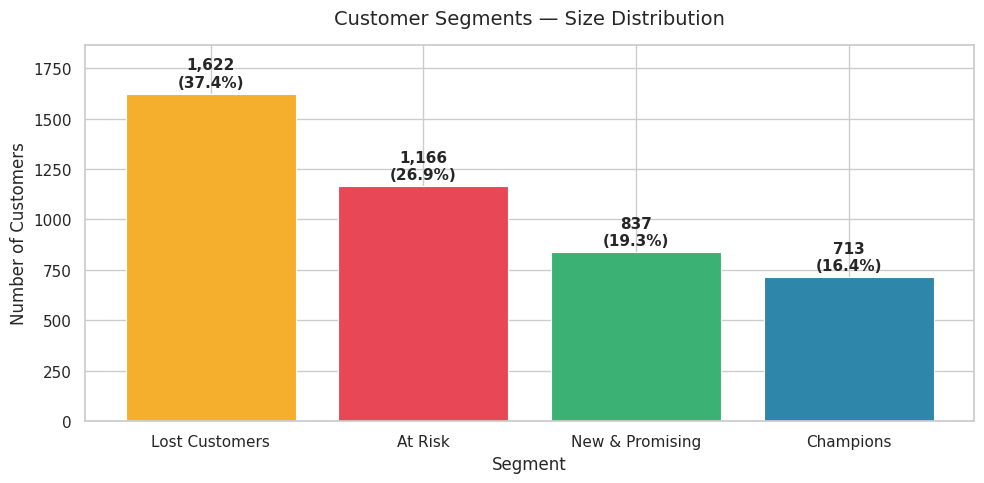

Saved!


In [4]:
segment_counts = rfm['Segment'].value_counts()

colors = {
    'Champions':       '#2E86AB',
    'At Risk':         '#E84855',
    'New & Promising': '#3BB273',
    'Lost Customers':  '#F6AE2D'
}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(segment_counts.index,
              segment_counts.values,
              color=[colors[s] for s in segment_counts.index],
              edgecolor='white', linewidth=0.8)

# Add count labels on top of each bar
for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{val:,}\n({val/len(rfm)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Segments — Size Distribution', fontsize=14, pad=15)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, max(segment_counts.values) * 1.15)

plt.tight_layout()
plt.savefig(f'{FIGURES}/segment_sizes.png', dpi=150)
plt.show()
print("Saved!")

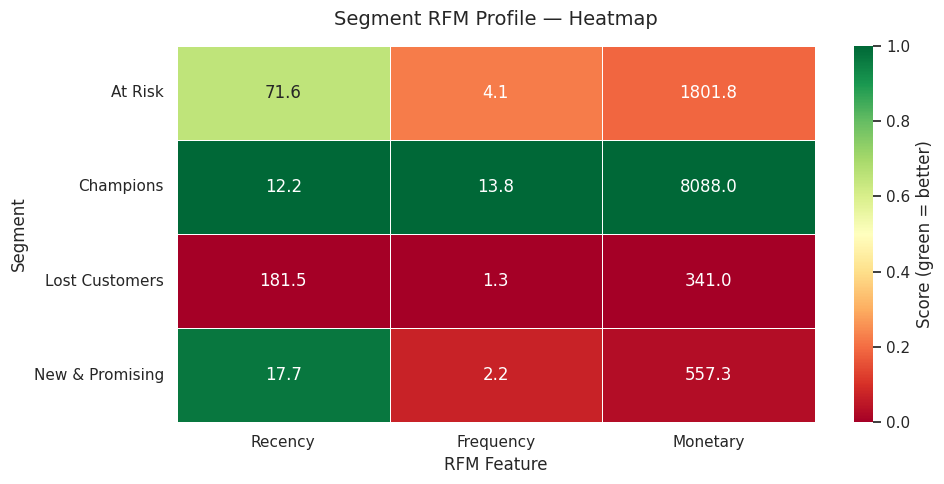

Saved!


In [5]:
profile = rfm.groupby('Segment').agg(
    Recency   = ('Recency',   'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary',  'mean')
).round(1)

# Normalize each column to 0-1 for heatmap coloring
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

# For Recency — lower is better, so flip it
profile_norm['Recency'] = 1 - profile_norm['Recency']

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(profile_norm,
            annot=profile,        # show actual values
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Score (green = better)'})

ax.set_title('Segment RFM Profile — Heatmap', fontsize=14, pad=15)
ax.set_xlabel('RFM Feature', fontsize=12)
ax.set_ylabel('Segment', fontsize=12)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES}/rfm_heatmap.png', dpi=150)
plt.show()
print("Saved!")

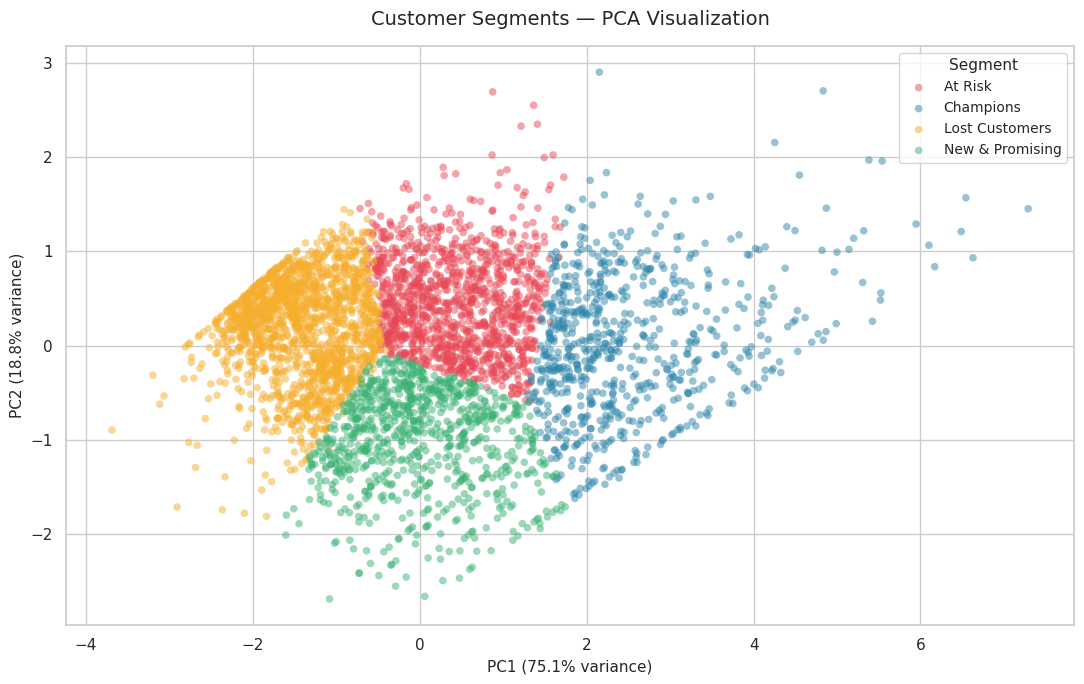

Variance explained: 93.9%
Saved!


In [6]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['Segment'] = rfm['Segment'].values

colors = {
    'Champions':       '#2E86AB',
    'At Risk':         '#E84855',
    'New & Promising': '#3BB273',
    'Lost Customers':  '#F6AE2D'
}

fig, ax = plt.subplots(figsize=(11, 7))

for segment, group in pca_df.groupby('Segment'):
    ax.scatter(group['PC1'], group['PC2'],
               label=segment,
               color=colors[segment],
               alpha=0.5, s=30, edgecolors='none')

ax.set_title('Customer Segments — PCA Visualization', fontsize=14, pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.legend(title='Segment', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES}/pca_clusters.png', dpi=150)
plt.show()

print(f"Variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print("Saved!")

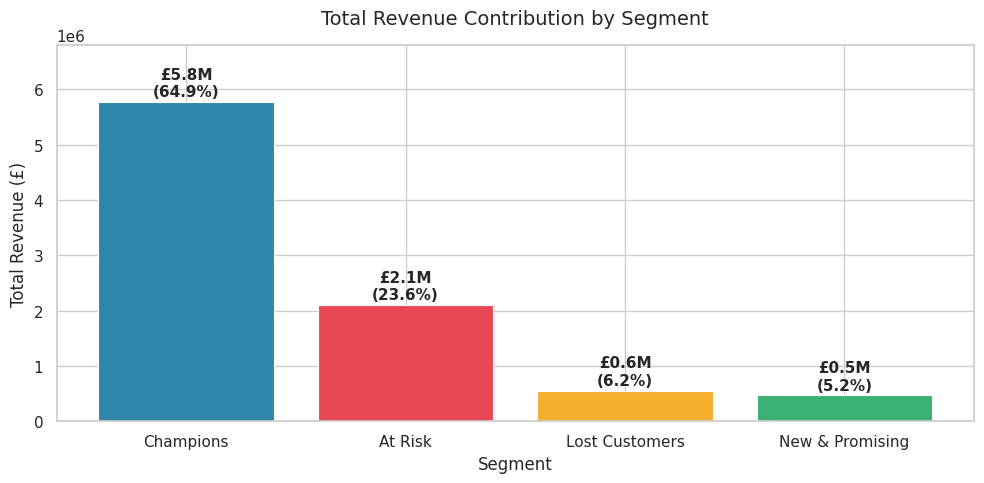

Saved!


In [7]:
revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
total   = revenue.sum()

colors = {
    'Champions':       '#2E86AB',
    'At Risk':         '#E84855',
    'New & Promising': '#3BB273',
    'Lost Customers':  '#F6AE2D'
}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(revenue.index,
              revenue.values,
              color=[colors[s] for s in revenue.index],
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50000,
            f'£{val/1e6:.1f}M\n({val/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Total Revenue Contribution by Segment', fontsize=14, pad=15)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Total Revenue (£)', fontsize=12)
ax.set_ylim(0, max(revenue.values) * 1.18)

plt.tight_layout()
plt.savefig(f'{FIGURES}/revenue_by_segment.png', dpi=150)
plt.show()
print("Saved!")

In [8]:
# ================================================
# VISUALIZATION SUMMARY
# ================================================
# Charts created:
#
# 1. segment_sizes.png
#    → Customer count per segment
#    → Lost Customers = largest group (37.4%)
#
# 2. rfm_heatmap.png
#    → RFM scores per segment (green = better)
#    → Champions = all green, Lost = all red
#
# 3. pca_clusters.png
#    → All 4,338 customers plotted in 2D
#    → 93.9% variance explained
#    → Clear cluster separation visible
#
# 4. revenue_by_segment.png
#    → Champions (16% of customers) = 64.9% revenue
#    → Classic 80/20 rule confirmed
#
# KEY BUSINESS FINDING:
# Protect Champions at all costs.
# Re-engage At Risk before they become Lost.
# ================================================